In [ ]:
!pip install -r requirements.txt

# Quantile Regression IR → MP2

Phiên bản cuối gọn để dùng cho báo cáo và triển khai ESP32.

Pipeline:

```text
IR_raw
  ↓
Preprocessing hiện tại
  ↓
7 temporal features
  ↓
QuantileRegressor (q=0.35)
  ↓
Baseline gate
  ↓
EMA output 0.25 s
  ↓
MP2_pred
```

Không sử dụng `MP2_DO`.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True

## 1. Cấu trúc thư mục

```text
project/
├── train_linear_practical_offset_fixed_train_test.ipynb
├── input/
│   ├── train/
│   │   └── *.csv
│   └── test/
│       └── *.csv
└── output/
```


In [2]:
ROOT = Path.cwd()

TRAIN_DIR = ROOT / "input" / "train"
TEST_DIR  = ROOT / "input" / "test"
OUTPUT_DIR = ROOT / "output"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED = {"IR_raw", "MP2_AO_raw"}
DEFAULT_FS = 20.0

## 2. Đọc dữ liệu

Chỉ giữ:
- `sample`
- `time_s`
- `time_from_trigger_s`
- `IR_raw`
- `MP2_AO_raw`

`MP2_DO` bị bỏ hoàn toàn.


In [3]:
def load_folder(folder, split):
    files = sorted(folder.glob("*.csv"))

    if not files:
        raise FileNotFoundError(f"Không tìm thấy CSV trong {folder}")

    result = []

    for path in files:
        df = pd.read_csv(path)

        missing = REQUIRED - set(df.columns)
        if missing:
            raise ValueError(f"{path.name} thiếu cột: {missing}")

        keep = [
            c for c in [
                "sample",
                "time_s",
                "time_from_trigger_s",
                "IR_raw",
                "MP2_AO_raw"
            ]
            if c in df.columns
        ]

        df = df[keep].copy()
        df["file"] = path.name
        df["split"] = split

        result.append(df)

    return result


train_files = load_folder(TRAIN_DIR, "train")
test_files  = load_folder(TEST_DIR, "test")

print("Train:", len(train_files))
print("Test :", len(test_files))

Train: 48
Test : 21


## 3. Tương quan IR–MP2 theo từng file


In [4]:
def corr_table(file_dfs):
    rows = []

    for df in file_dfs:
        rows.append({
            "split": df["split"].iloc[0],
            "file": df["file"].iloc[0],
            "samples": len(df),
            "Pearson": df["IR_raw"].corr(df["MP2_AO_raw"], method="pearson"),
            "Spearman": df["IR_raw"].corr(df["MP2_AO_raw"], method="spearman")
        })

    return pd.DataFrame(rows)


correlation_df = pd.concat([
    corr_table(train_files),
    corr_table(test_files)
], ignore_index=True)

correlation_df

,split,file,samples,Pearson,Spearman
0,train,giay1.csv,1410,0.673388,0.618024
1,train,giay10.csv,744,0.793737,0.864819
2,train,giay11.csv,829,0.743883,0.772735
3,train,giay2.csv,937,0.859217,0.895928
4,train,giay3.csv,804,0.880200,0.910059
...,...,...,...,...,...
64,test,log28.csv,1013,0.784103,0.935686
65,test,log3.csv,804,0.880200,0.910059
66,test,log35.csv,1227,0.795637,0.875832
67,test,log7.csv,903,0.849509,0.816517


## 4. Hàm hỗ trợ thời gian


In [5]:
def estimate_fs(df):
    if "time_s" in df.columns and len(df) > 2:
        dt = np.diff(df["time_s"].to_numpy(float))
        dt = dt[np.isfinite(dt) & (dt > 0)]

        if len(dt):
            return 1.0 / np.median(dt)

    return DEFAULT_FS


def seconds_to_samples(seconds, fs):
    return max(1, int(round(seconds * fs)))

## 5. Preprocessing thực tế

### Baseline correction

Nếu có `time_from_trigger_s`, baseline là median IR trước trigger:

\[
IR_0 = median(IR,\; t<0)
\]

Sau đó:

\[
IR_{corr} = \max(IR_{raw} - IR_0, 0)
\]

Nếu file không có thời gian trigger, dùng khoảng 3 giây đầu làm baseline.

### Lọc IR

Dùng EMA causal với hằng số thời gian khoảng 0.25 s để giảm nhiễu nhưng vẫn giữ đáp ứng nhanh.


In [6]:
def preprocess_ir(df):
    out = df.copy().reset_index(drop=True)
    fs = estimate_fs(out)
    dt = 1.0 / fs

    ir = out["IR_raw"].astype(float)

    if "time_from_trigger_s" in out.columns:
        baseline_values = ir[out["time_from_trigger_s"] < 0]

        if len(baseline_values) >= 3:
            baseline = float(baseline_values.median())
        else:
            baseline = float(ir.iloc[:seconds_to_samples(3, fs)].median())
    else:
        baseline = float(ir.iloc[:seconds_to_samples(3, fs)].median())

    ir_corrected = (ir - baseline).clip(lower=0)

    tau_filter = 0.25
    alpha = 1.0 - np.exp(-dt / tau_filter)

    ir_filtered = ir_corrected.ewm(
        alpha=alpha,
        adjust=False
    ).mean()

    out["IR_baseline"] = baseline
    out["IR_corrected"] = ir_corrected
    out["IR_filtered"] = ir_filtered

    return out

## 6. Bộ feature gọn để triển khai lên ESP32

Chỉ dùng 8 feature:

1. `IR_filtered`
2. `IR_ema_1s`
3. `IR_ema_5s`
4. `IR_ema_15s`
5. `IR_slope_1s`
6. `IR_area_5s`
7. `IR_area_15s`
8. `IR_max_5s`

Lý do:
- current: mức IR hiện tại;
- EMA: "bộ nhớ" ngắn / vừa / dài;
- slope: đang tăng hay giảm;
- area: tổng mức tiếp xúc khói gần đây;
- max: mức IR lớn nhất vừa xuất hiện.

Tất cả đều causal, không dùng dữ liệu tương lai.


In [7]:
FEATURE_COLUMNS = [
    "IR_filtered",
    "IR_ema_1s",
    "IR_ema_5s",
    "IR_ema_15s",
    "IR_slope_1s",
    "IR_area_5s",
    "IR_area_15s",
    "IR_max_5s"
]


def extract_practical_features(df):
    out = preprocess_ir(df)
    fs = estimate_fs(out)
    dt = 1.0 / fs

    ir = out["IR_filtered"].astype(float)

    # EMA memories
    for seconds in [1, 5, 15]:
        alpha = 1.0 - np.exp(-dt / seconds)

        out[f"IR_ema_{seconds}s"] = ir.ewm(
            alpha=alpha,
            adjust=False
        ).mean()

    # Slope 1 s
    n1 = seconds_to_samples(1, fs)
    previous = ir.shift(n1).fillna(ir.iloc[0])

    out["IR_slope_1s"] = (ir - previous) / 1.0

    # Area / integral
    for seconds in [5, 15]:
        n = seconds_to_samples(seconds, fs)

        out[f"IR_area_{seconds}s"] = (
            ir.rolling(n, min_periods=1).sum() * dt
        )

    # Rolling max 5 s
    n5 = seconds_to_samples(5, fs)

    out["IR_max_5s"] = ir.rolling(
        n5,
        min_periods=1
    ).max()

    return out

## 7. Tạo feature riêng theo từng file


In [8]:
train_feature_files = [
    extract_practical_features(df)
    for df in train_files
]


test_feature_files = [
    extract_practical_features(df)
    for df in test_files
]

train_data = pd.concat(train_feature_files, ignore_index=True)
test_data  = pd.concat(test_feature_files, ignore_index=True)

train_data[FEATURE_COLUMNS + ["MP2_AO_raw"]].head()

,IR_filtered,IR_ema_1s,IR_ema_5s,IR_ema_15s,IR_slope_1s,IR_area_5s,IR_area_15s,IR_max_5s,MP2_AO_raw
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23


## 8. Xác định baseline MP2 từ tập train

Baseline MP2 chỉ được tính từ **tập train**, không sử dụng test.

Nếu có `time_from_trigger_s`, lấy các mẫu trước trigger (`t < 0`).
Nếu không có, lấy 3 giây đầu của mỗi file.

Dùng median để giảm ảnh hưởng của nhiễu/outlier.


In [9]:
def get_mp2_baseline(file_dfs):
    values = []

    for df in file_dfs:
        fs = estimate_fs(df)

        if "time_from_trigger_s" in df.columns:
            baseline_values = df.loc[
                df["time_from_trigger_s"] < 0,
                "MP2_AO_raw"
            ]

            if len(baseline_values) < 3:
                n = seconds_to_samples(3, fs)
                baseline_values = df["MP2_AO_raw"].iloc[:n]
        else:
            n = seconds_to_samples(3, fs)
            baseline_values = df["MP2_AO_raw"].iloc[:n]

        values.extend(
            baseline_values.to_numpy(dtype=float)
        )

    return float(np.median(values))


MP2_BASELINE = get_mp2_baseline(train_files)

print(f"MP2 baseline từ train = {MP2_BASELINE:.2f} ADC")

MP2 baseline từ train = 89.00 ADC


## 9. Baseline gate để xử lý offset

Định nghĩa mức hoạt động IR:

\[
A = \max(
IR_{filtered},
IR_{ema1},
IR_{ema5},
IR_{ema15},
IR_{max5}
)
\]

Gate:

\[
g = clip(A/T,\;0,\;1)
\]

Prediction cuối:

\[
MP2_{final}
=
MP2_{baseline}
+
g(MP2_{raw}-MP2_{baseline})
\]

Khi \(A=0\):

\[
MP2_{final}=MP2_{baseline}
\]

Khi \(A \ge T\):

\[
MP2_{final}=MP2_{raw}
\]

Chỉ có một tham số `T`; tham số này được chọn bằng **validation set**, không dùng test.


In [10]:
def apply_baseline_gate(
    df,
    raw_prediction,
    threshold,
    mp2_baseline
):
    activity = np.maximum.reduce([
        df["IR_filtered"].to_numpy(float),
        df["IR_ema_1s"].to_numpy(float),
        df["IR_ema_5s"].to_numpy(float),
        df["IR_ema_15s"].to_numpy(float),
        df["IR_max_5s"].to_numpy(float)
    ])

    gate = np.clip(
        activity / threshold,
        0.0,
        1.0
    )

    final_prediction = (
        mp2_baseline
        + gate * (raw_prediction - mp2_baseline)
    )

    return np.clip(
        final_prediction,
        0.0,
        4095.0
    )

## 10. Bộ feature cuối

Giữ 7 feature:

```text
IR_filtered
IR_ema_1s
IR_ema_5s
IR_ema_15s
IR_area_5s
IR_area_15s
IR_max_5s
```




In [11]:
FEATURE_COLUMNS = [
    "IR_filtered",
    "IR_ema_1s",
    "IR_ema_5s",
    "IR_ema_15s",
    "IR_area_5s",
    "IR_area_15s",
    "IR_max_5s"
]

print("Số feature:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS)


Số feature: 7
['IR_filtered', 'IR_ema_1s', 'IR_ema_5s', 'IR_ema_15s', 'IR_area_5s', 'IR_area_15s', 'IR_max_5s']


## 11. Cấu hình baseline gate và EMA output


In [12]:
GATE_THRESHOLD = 400.0
OUTPUT_EMA_TAU_S = 0.25
QUANTILE = 0.375

print("MP2 baseline:", MP2_BASELINE)
print("Gate threshold:", GATE_THRESHOLD)
print("Output EMA tau:", OUTPUT_EMA_TAU_S, "s")
print("Quantile:", QUANTILE)


MP2 baseline: 89.0
Gate threshold: 400.0
Output EMA tau: 0.25 s
Quantile: 0.375


## 12. Train Quantile Regression


In [13]:
X_train = train_data[FEATURE_COLUMNS]
y_train = train_data["MP2_AO_raw"]

# StandardScaler chỉ dùng lúc train để QuantileRegressor ổn định số học.
# Sau train, hệ số được quy đổi về feature gốc để ESP32 không cần scaler.
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(
    X_train
)

model = QuantileRegressor(
    quantile=QUANTILE,
    alpha=0.0,
    solver="highs"
)

model.fit(
    X_train_scaled,
    y_train
)

# Quy đổi ngược về phương trình trên feature gốc:
# y = deploy_intercept + sum(deploy_coef[i] * feature[i])
deploy_coef = (
    model.coef_
    / feature_scaler.scale_
)

deploy_intercept = (
    model.intercept_
    - np.sum(
        model.coef_
        * feature_scaler.mean_
        / feature_scaler.scale_
    )
)

print("Đã train QuantileRegressor")
print("Quantile:", QUANTILE)
print("Số feature:", len(FEATURE_COLUMNS))
print("Intercept triển khai:", deploy_intercept)


Đã train QuantileRegressor
Quantile: 0.375
Số feature: 7
Intercept triển khai: 539.3666043270216


## 13. Công thức mô hình triển khai

Sau khi quy đổi hệ số về feature gốc, mô hình triển khai vẫn có dạng:

\[
MP2_{raw}
=
b + \sum_i w_i x_i
\]

Bảng dưới đây hiển thị intercept và coefficient của 7 feature.


In [14]:
coef_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "coefficient": deploy_coef
})

print("Quantile:", QUANTILE)
print("Intercept:", deploy_intercept)
coef_df


Quantile: 0.375
Intercept: 539.3666043270216


,feature,coefficient
0,IR_filtered,0.005027
1,IR_ema_1s,0.366430
2,IR_ema_5s,-0.443136
3,IR_ema_15s,-0.133796
4,IR_area_5s,-0.062876
5,IR_area_15s,0.029431
6,IR_max_5s,0.617684


## 14. Lưu model


In [15]:
model_path = OUTPUT_DIR / "linear_ir_to_mp2.joblib"

joblib.dump({
    "model": model,
    "scaler": feature_scaler,
    "deploy_coef": np.asarray(
        deploy_coef,
        dtype=float
    ),
    "deploy_intercept": float(
        deploy_intercept
    ),
    "quantile": QUANTILE,
    "features": FEATURE_COLUMNS,
    "mp2_baseline": MP2_BASELINE,
    "gate_threshold": GATE_THRESHOLD,
    "output_ema_tau_s": OUTPUT_EMA_TAU_S
}, model_path)

print("Saved:", model_path)


Saved: c:\Users\hieut\Desktop\TTTN\output\linear_ir_to_mp2.joblib


## 15. Load lại model trước khi test


In [16]:
bundle = joblib.load(model_path)

loaded_model = bundle["model"]
loaded_scaler = bundle["scaler"]
loaded_deploy_coef = np.asarray(
    bundle["deploy_coef"],
    dtype=float
)
loaded_deploy_intercept = float(
    bundle["deploy_intercept"]
)
loaded_quantile = float(
    bundle["quantile"]
)

loaded_features = bundle["features"]
loaded_mp2_baseline = bundle["mp2_baseline"]
loaded_gate_threshold = bundle["gate_threshold"]
loaded_output_ema_tau_s = bundle["output_ema_tau_s"]

print("Loaded model with", len(loaded_features), "features")
print("Quantile:", loaded_quantile)
print("MP2 baseline:", loaded_mp2_baseline)
print("Gate threshold:", loaded_gate_threshold)
print("Output EMA tau:", loaded_output_ema_tau_s, "s")


Loaded model with 7 features
Quantile: 0.375
MP2 baseline: 89.0
Gate threshold: 400.0
Output EMA tau: 0.25 s


## 16. EMA làm mượt đầu ra


In [17]:
def smooth_output_ema(
    values,
    fs,
    initial_value,
    tau_s
):
    values = np.asarray(
        values,
        dtype=float
    )

    dt = 1.0 / fs
    alpha = 1.0 - np.exp(
        -dt / tau_s
    )

    output = np.empty_like(
        values,
        dtype=float
    )

    state = float(initial_value)

    for i, value in enumerate(values):
        state += alpha * (
            value - state
        )
        output[i] = state

    return output


## 17. Hàm prediction cuối - Model Pred

Pipeline nội bộ:

```text
QuantileRegressor q=0.35
→ clip ADC
→ baseline gate
→ EMA output 0.25 s
```


In [18]:
def predict_mp2(df):
    X = df[loaded_features]

    X_scaled = loaded_scaler.transform(
        X
    )

    raw_prediction = loaded_model.predict(
        X_scaled
    )

    raw_prediction = np.clip(
        raw_prediction,
        0.0,
        4095.0
    )

    gated_prediction = apply_baseline_gate(
        df,
        raw_prediction,
        threshold=loaded_gate_threshold,
        mp2_baseline=loaded_mp2_baseline
    )

    model_pred = smooth_output_ema(
        gated_prediction,
        fs=estimate_fs(df),
        initial_value=loaded_mp2_baseline,
        tau_s=loaded_output_ema_tau_s
    )

    model_pred = np.clip(
        model_pred,
        0.0,
        4095.0
    )

    return model_pred


## 18. Đánh giá từng file test


In [19]:
rows = []
all_true = []
all_pred = []

for df in test_feature_files:
    file_name = df["file"].iloc[0]

    y_true = df[
        "MP2_AO_raw"
    ].to_numpy(float)

    model_pred = predict_mp2(df)

    all_true.extend(y_true)
    all_pred.extend(model_pred)

    rows.append({
        "file": file_name,
        "R2": r2_score(
            y_true,
            model_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                model_pred
            )
        ),
        "MAE": mean_absolute_error(
            y_true,
            model_pred
        )
    })

test_results = pd.DataFrame(rows)
test_results


,file,R2,RMSE,MAE
0,giay10.csv,0.305326,709.385220,575.013855
1,giay11.csv,0.770067,464.110427,325.564350
2,giay3.csv,0.903663,294.610208,225.208295
3,giay4.csv,-0.358420,688.607923,533.658440
4,giay5.csv,0.740850,504.271695,403.418443
5,giay6.csv,0.746174,470.421808,357.165982
6,giay7.csv,0.915615,221.539524,168.308659
7,giay8.csv,0.706974,474.465559,339.284142
8,giay9.csv,0.813063,329.705592,257.699043
9,log12.csv,0.606915,607.659445,460.570607


## 19. Metric tổng trên toàn bộ test


In [20]:
all_true = np.asarray(
    all_true
)

all_pred = np.asarray(
    all_pred
)

overall = {
    "R2": r2_score(
        all_true,
        all_pred
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            all_true,
            all_pred
        )
    ),
    "MAE": mean_absolute_error(
        all_true,
        all_pred
    )
}

overall


{'R2': 0.7066023051616113,
 'RMSE': np.float64(490.50662406823426),
 'MAE': 353.83482231312087}

## 20. Vẽ MP2 thực tế và Model Pred


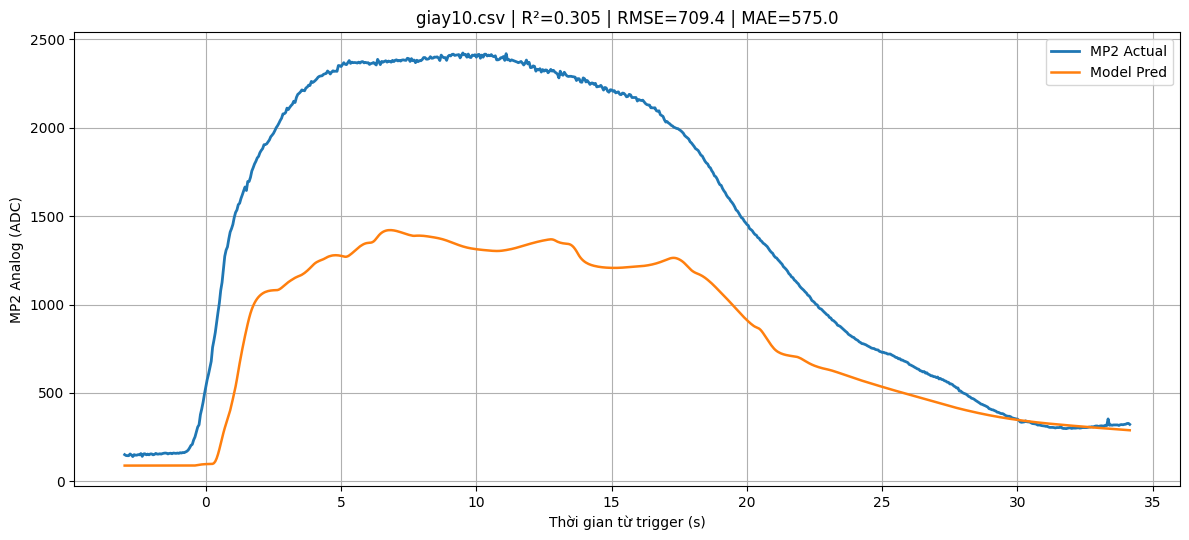

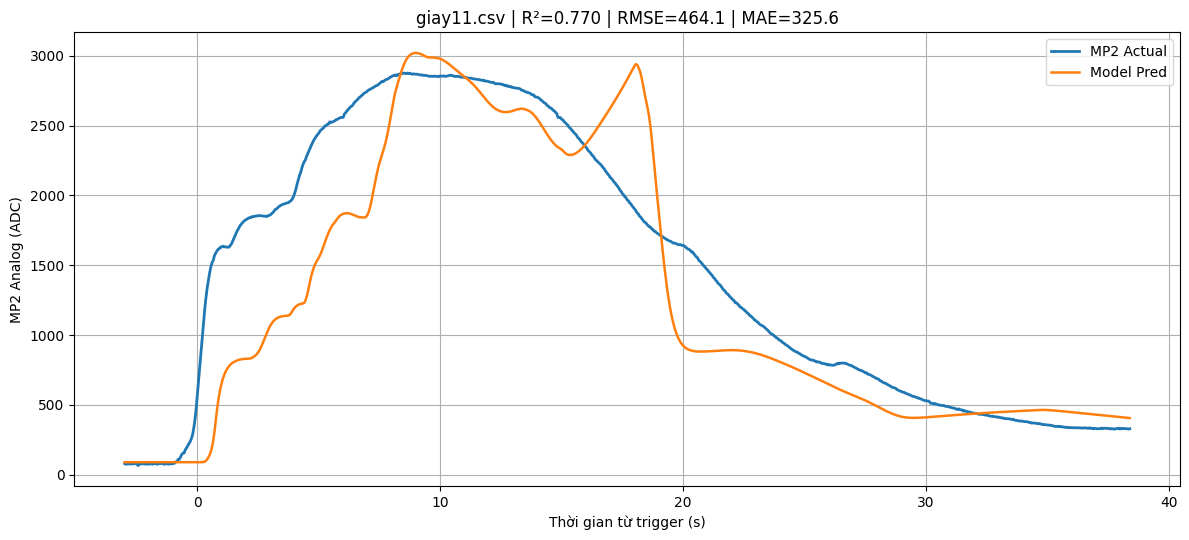

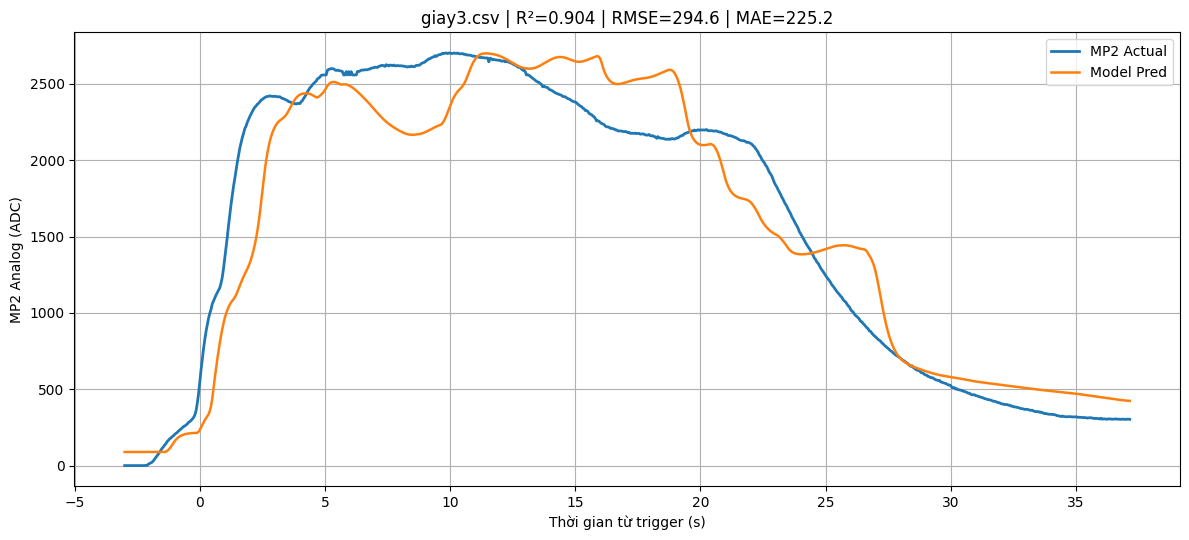

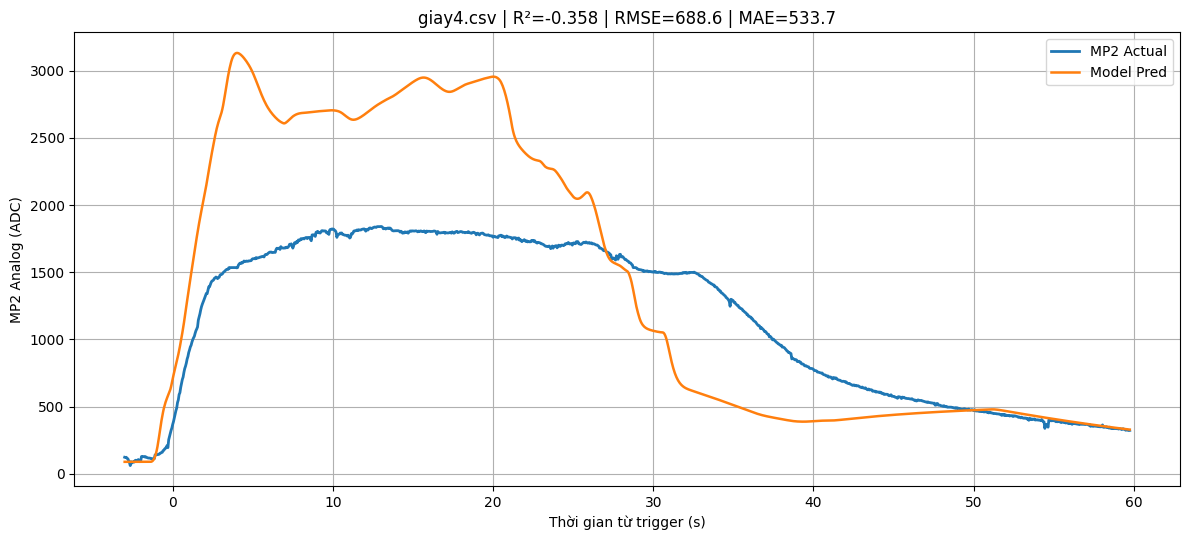

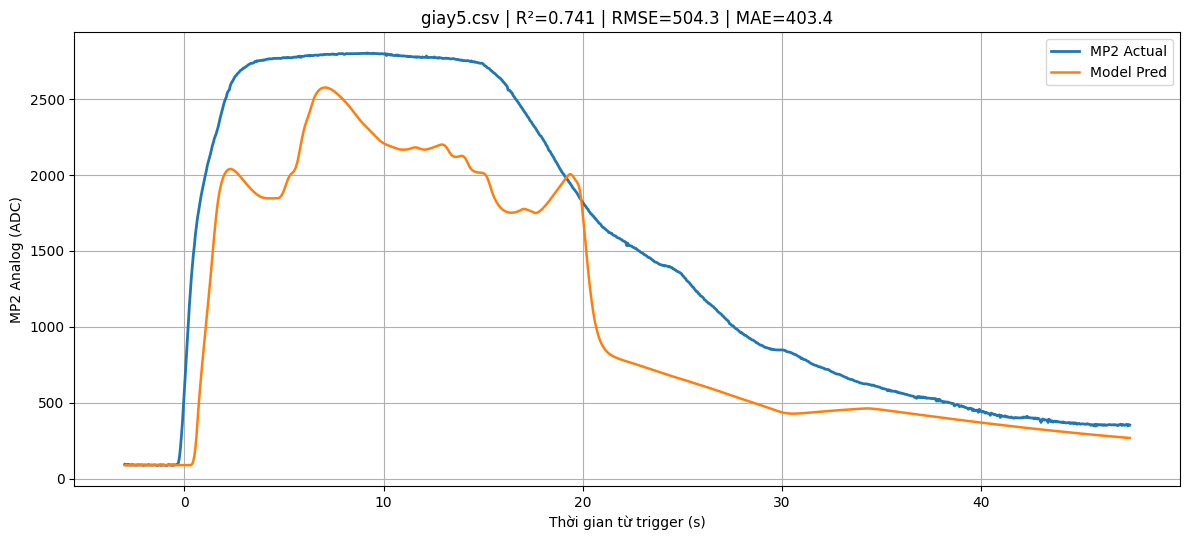

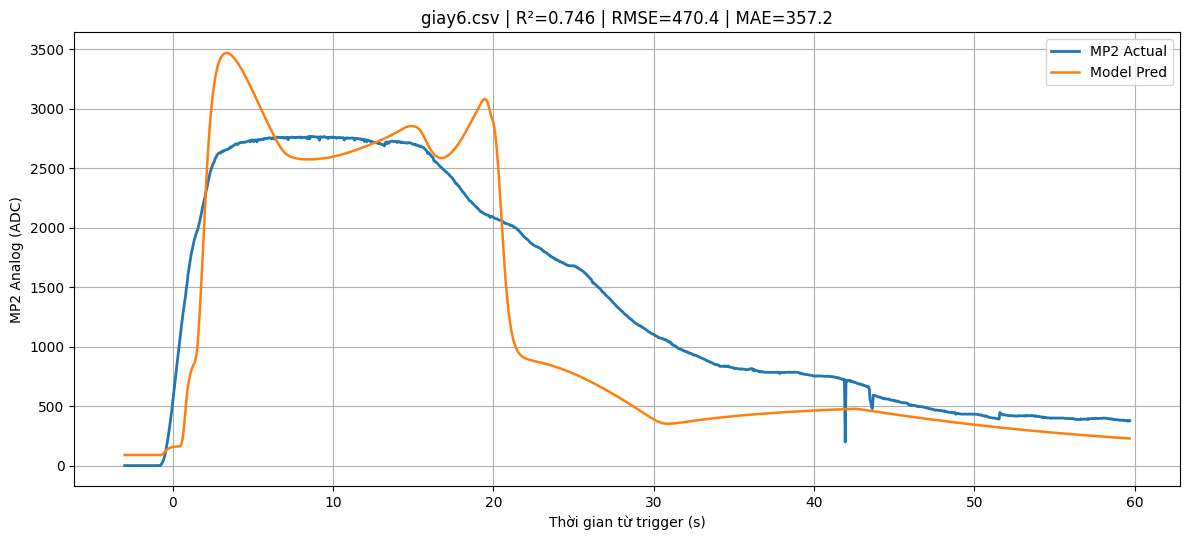

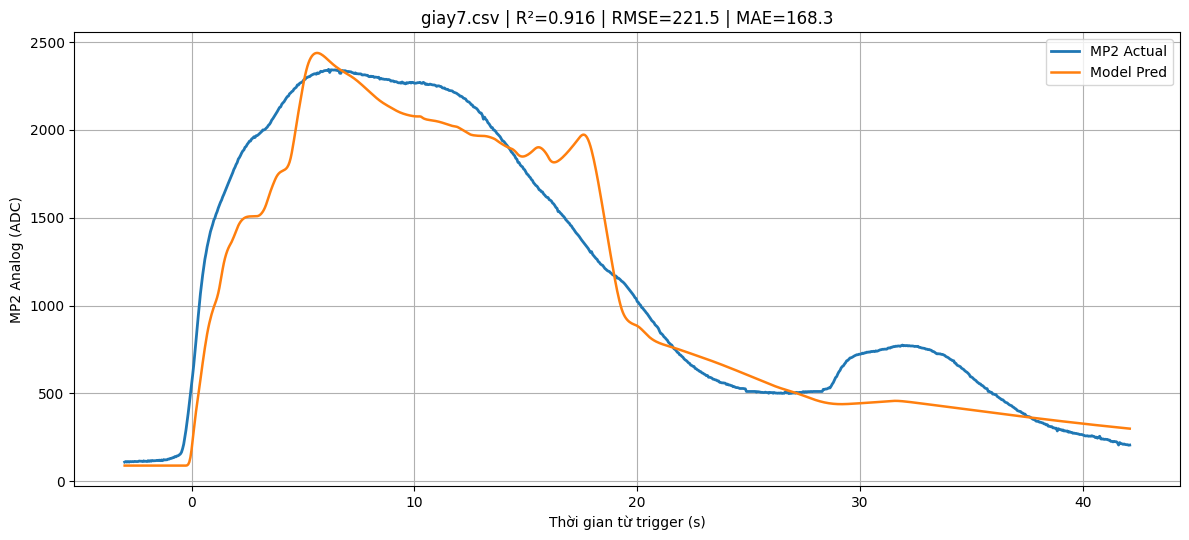

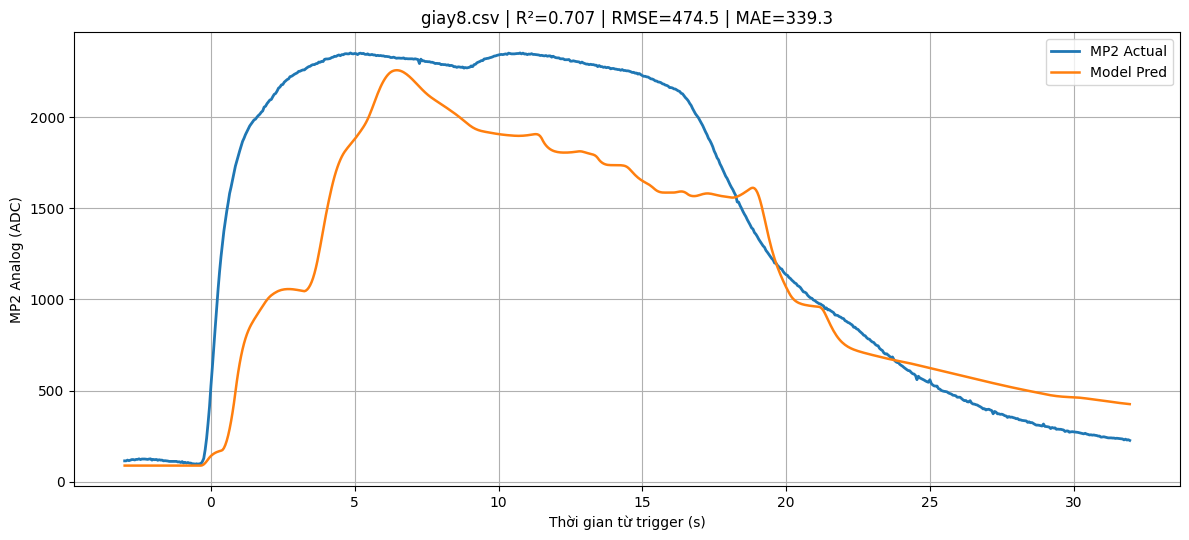

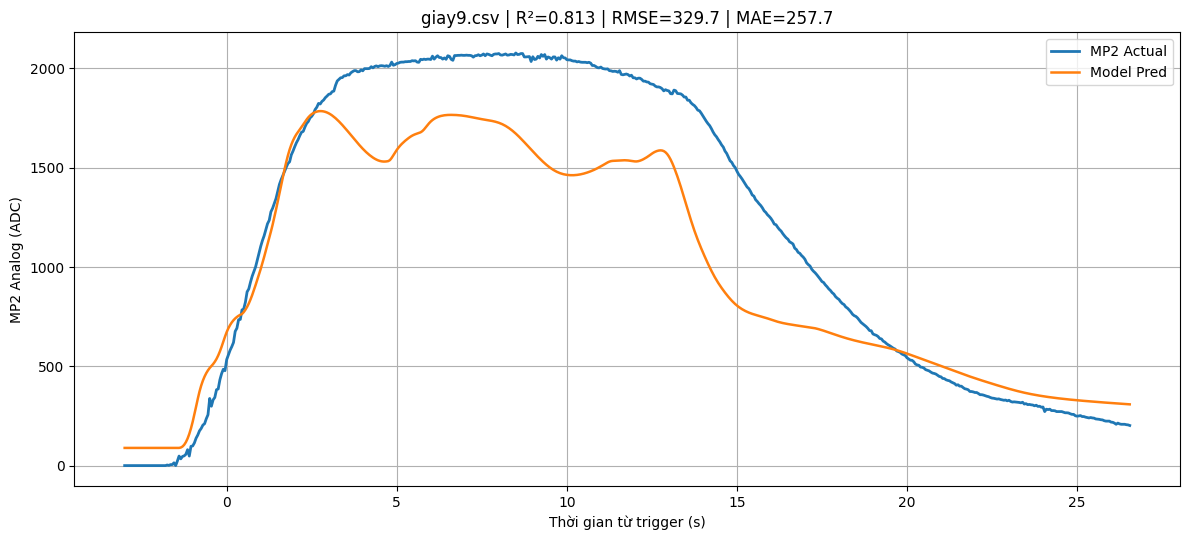

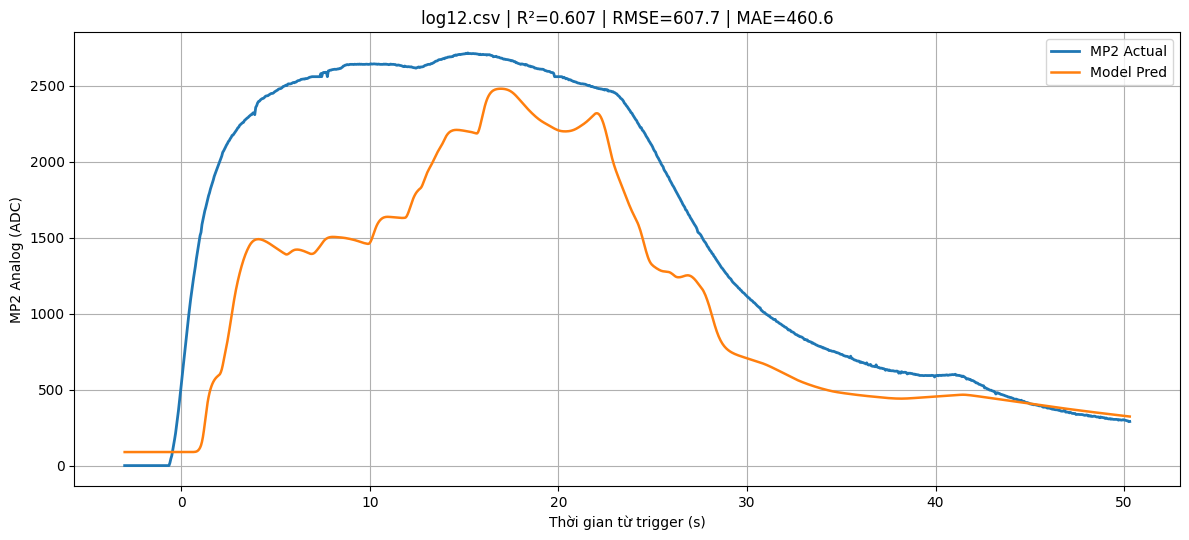

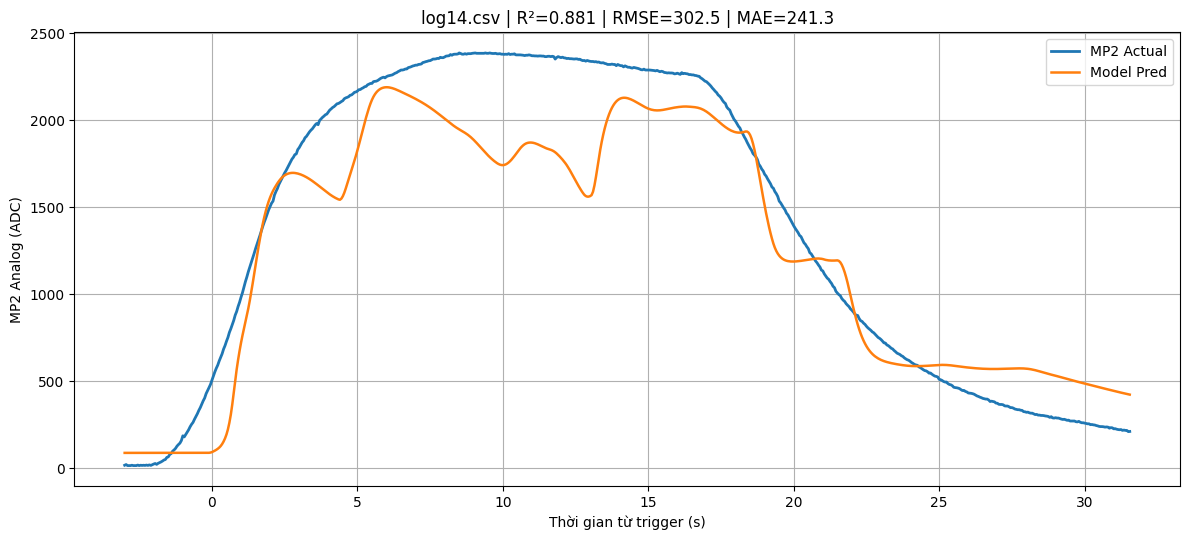

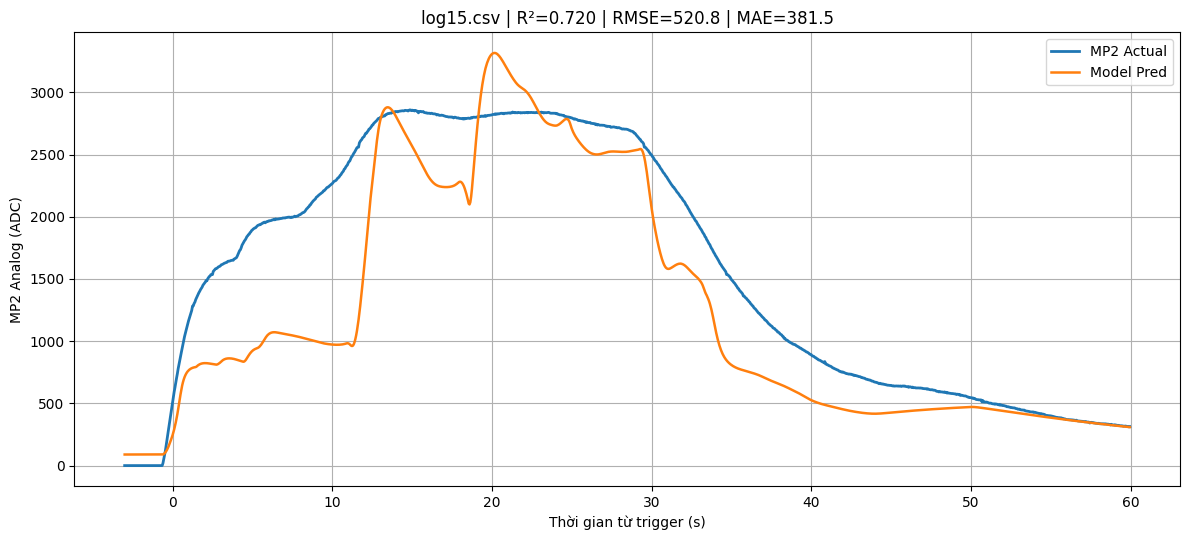

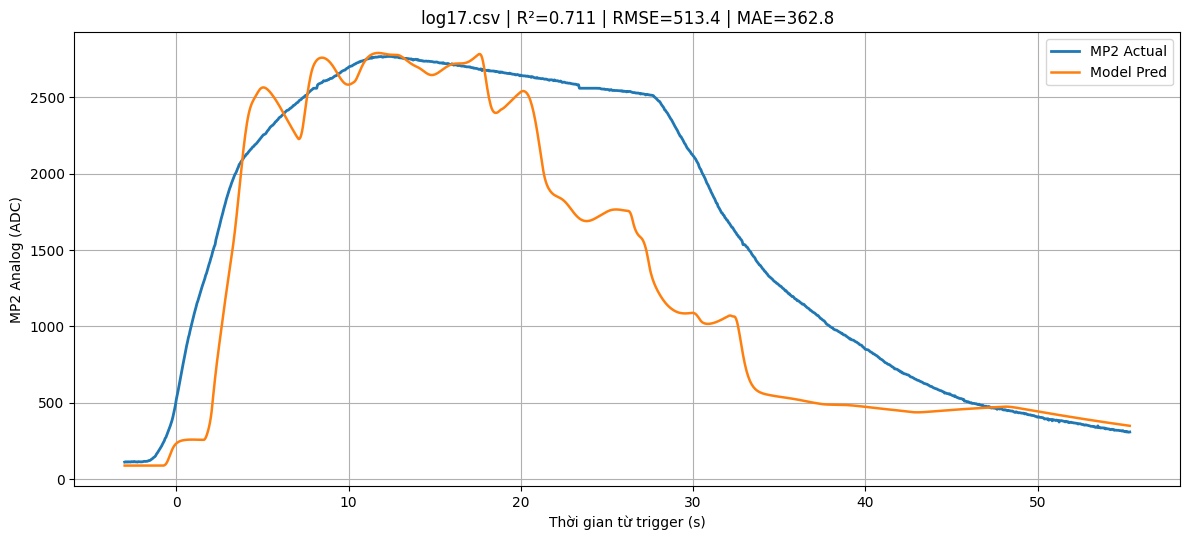

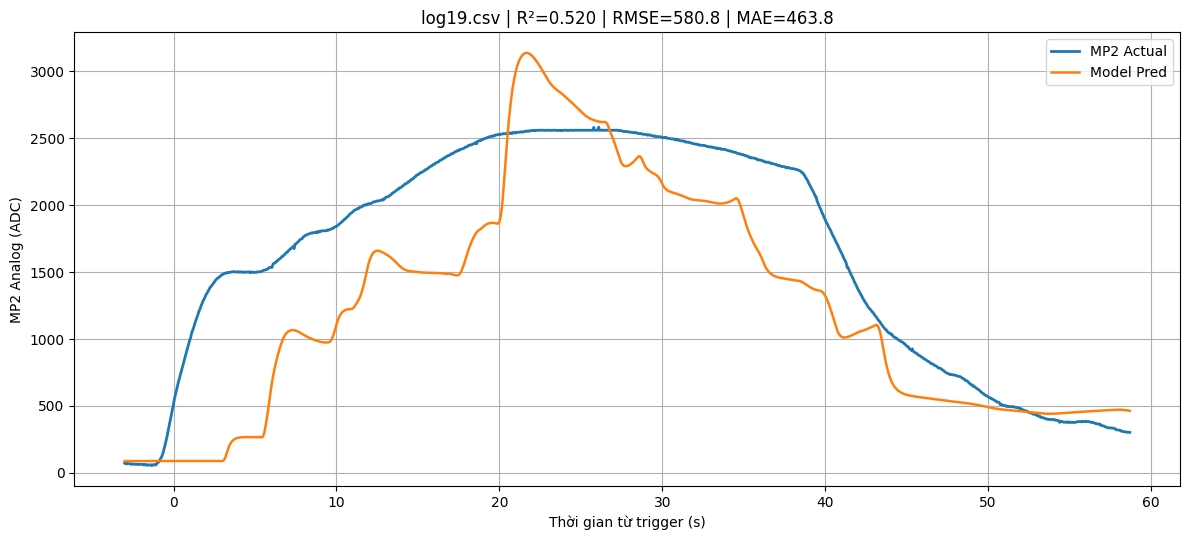

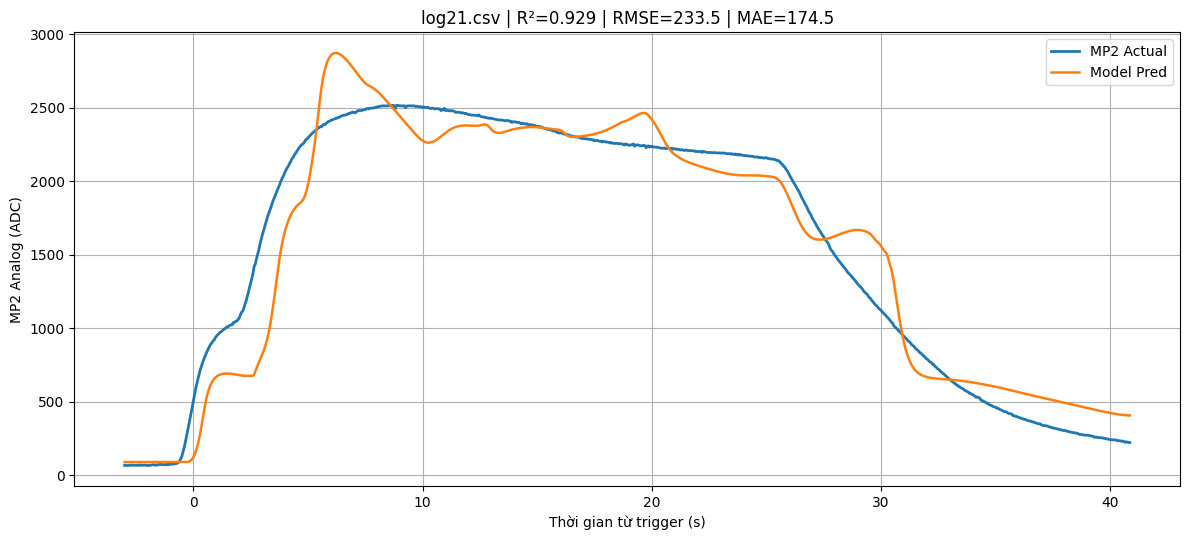

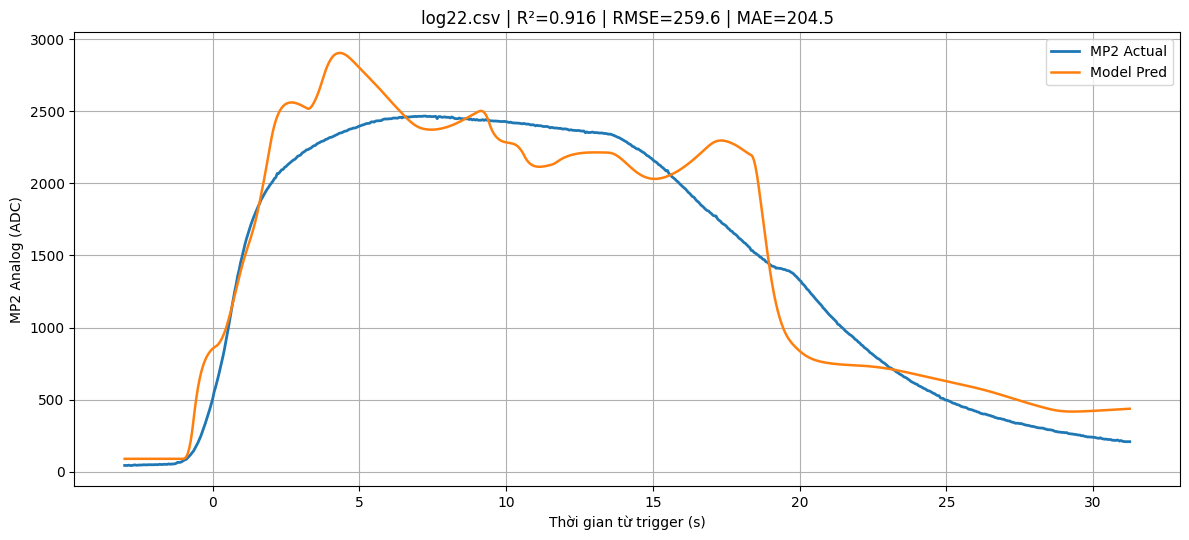

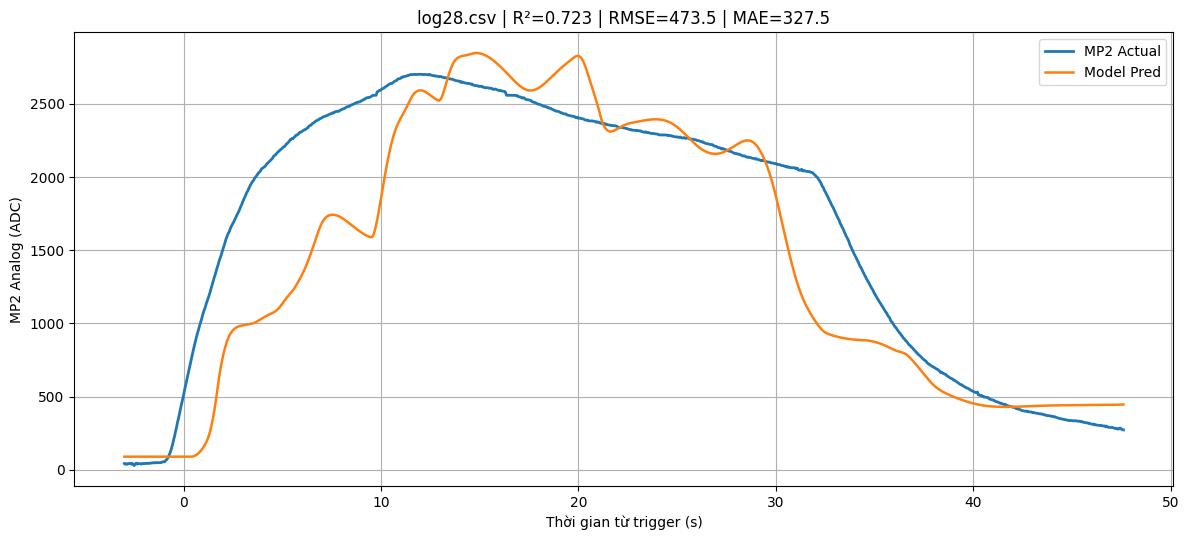

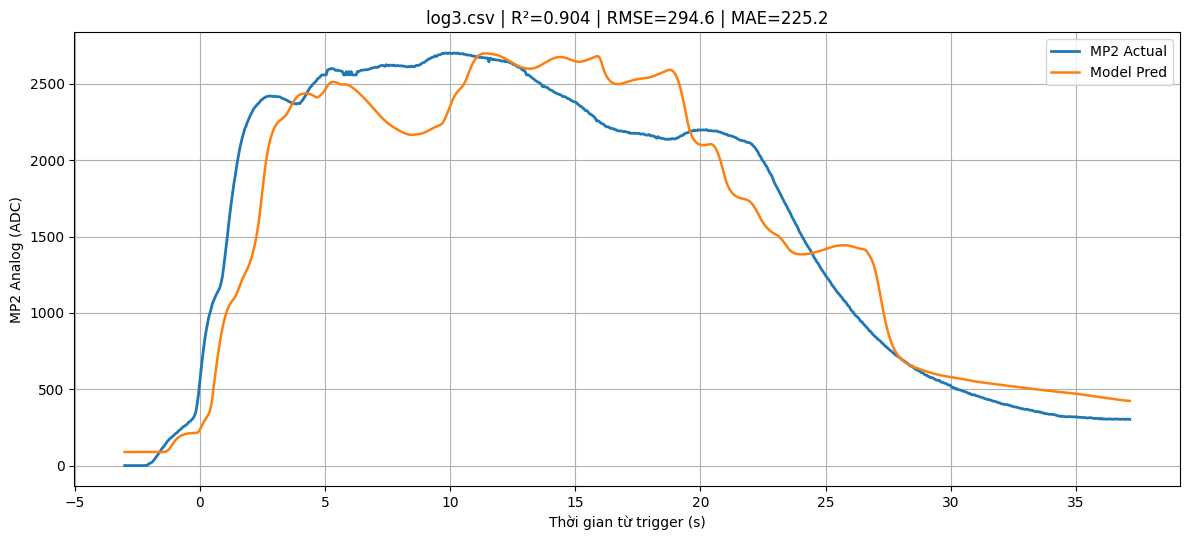

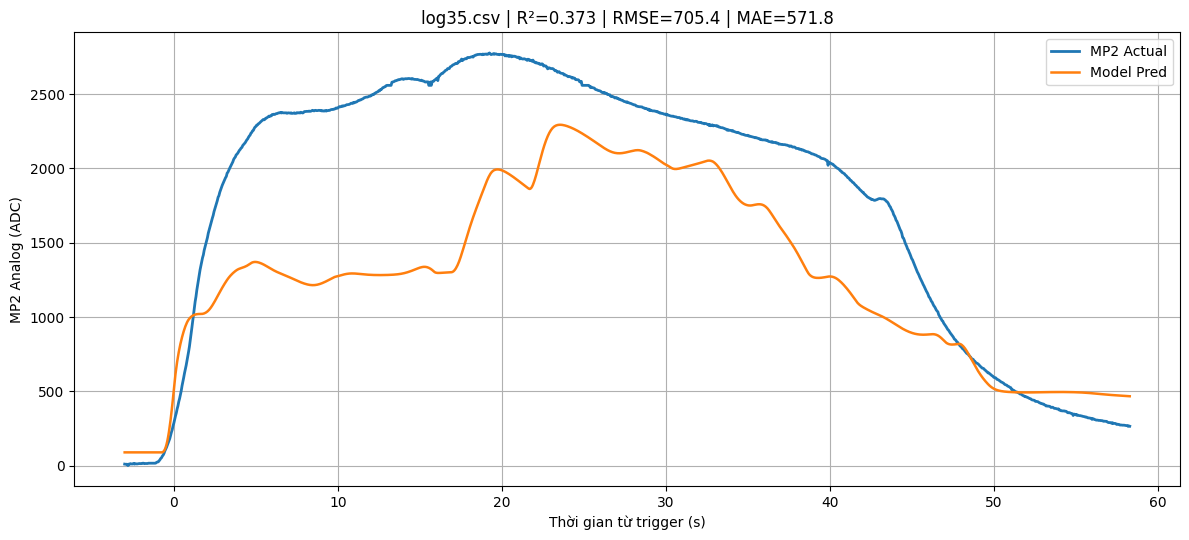

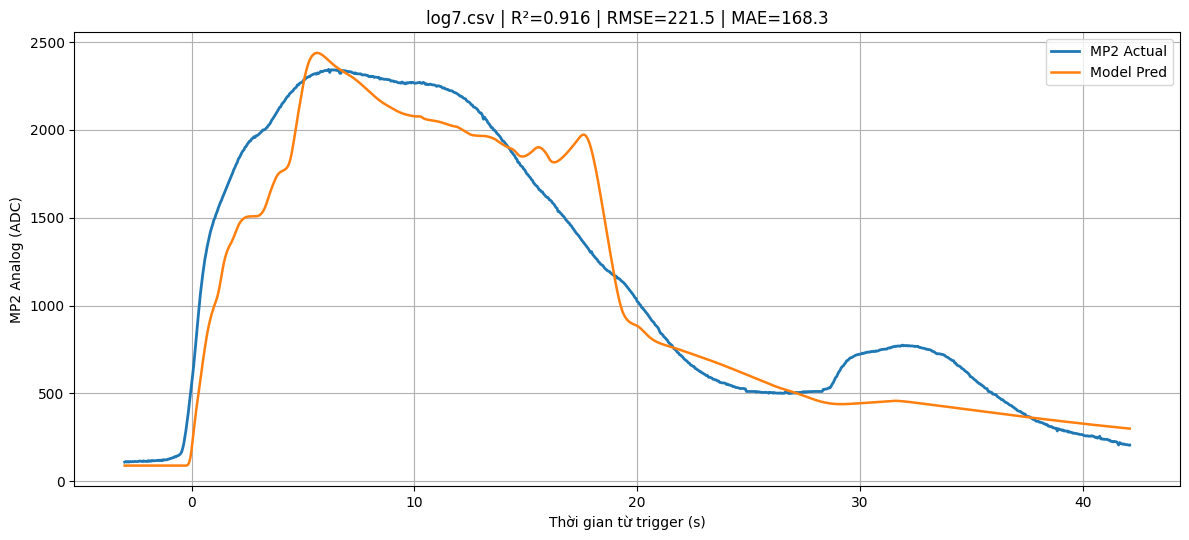

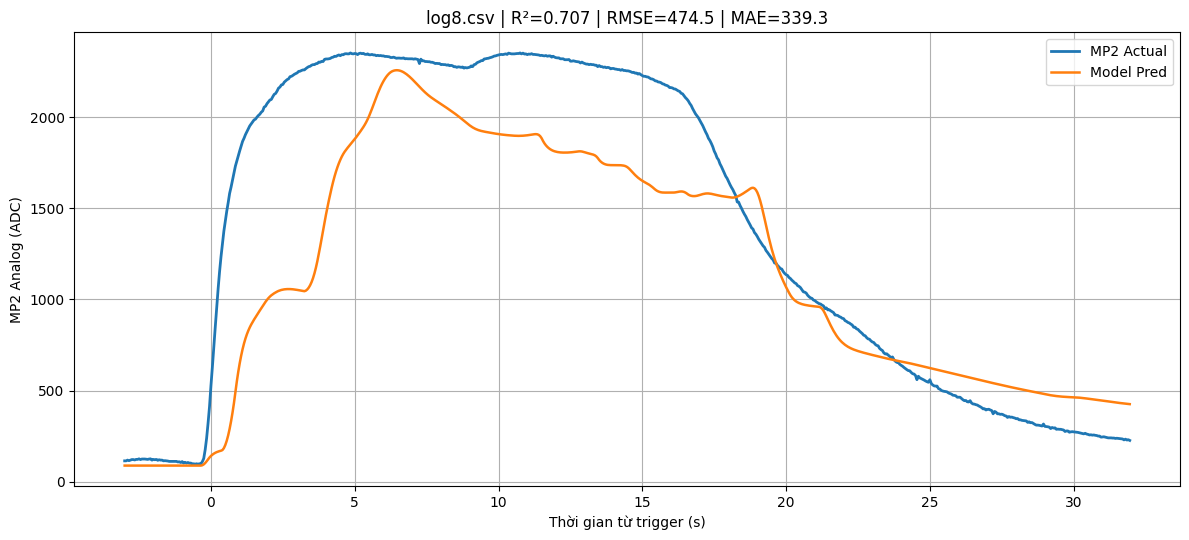

In [21]:
for df in test_feature_files:
    file_name = df["file"].iloc[0]

    y_true = df[
        "MP2_AO_raw"
    ].to_numpy(float)

    model_pred = predict_mp2(df)

    if "time_from_trigger_s" in df.columns:
        x = df["time_from_trigger_s"]
        xlabel = "Thời gian từ trigger (s)"
    elif "time_s" in df.columns:
        x = df["time_s"]
        xlabel = "Thời gian (s)"
    else:
        x = np.arange(len(df))
        xlabel = "Sample"

    r2 = r2_score(
        y_true,
        model_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            model_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        model_pred
    )

    plt.figure(
        figsize=(12, 5.5)
    )

    plt.plot(
        x,
        y_true,
        label="MP2 Actual",
        linewidth=2
    )

    plt.plot(
        x,
        model_pred,
        label="Model Pred",
        linewidth=1.8
    )

    plt.xlabel(xlabel)
    plt.ylabel("MP2 Analog (ADC)")

    plt.title(
        f"{file_name} | "
        f"R²={r2:.3f} | "
        f"RMSE={rmse:.1f} | "
        f"MAE={mae:.1f}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


## 21. Lưu kết quả test


In [22]:
result_path = OUTPUT_DIR / "test_results.csv"

test_results.to_csv(
    result_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", result_path)


Saved: c:\Users\hieut\Desktop\TTTN\output\test_results.csv


## 22. Xuất hệ số cho ESP32

Notebook xuất trực tiếp:
- intercept;
- MP2 baseline;
- gate threshold;
- output EMA tau;
- 7 coefficient;
- thứ tự feature.


In [23]:
header_path = OUTPUT_DIR / "linear_ir_mp2.h"

lines = [
    "#pragma once",
    "",
    "// Auto-generated from train_linear_clean.ipynb",
    f"static const float MP2_INTERCEPT = {loaded_deploy_intercept:.9f}f;",
    f"static const float MP2_BASELINE = {loaded_mp2_baseline:.9f}f;",
    f"static const float MP2_GATE_THRESHOLD = {loaded_gate_threshold:.9f}f;",
    f"static const float MP2_OUTPUT_EMA_TAU_S = {loaded_output_ema_tau_s:.6f}f;",
    "",
    f"static const int MP2_NUM_FEATURES = {len(loaded_features)};",
    "",
    "static const float MP2_COEFFICIENTS[MP2_NUM_FEATURES] = {"
]

for coef in loaded_deploy_coef:
    lines.append(
        f"    {coef:.9f}f,"
    )

lines += [
    "};",
    "",
    "// Feature order:"
]

for i, feature in enumerate(
    loaded_features
):
    lines.append(
        f"// {i}: {feature}"
    )

header_path.write_text(
    "\n".join(lines),
    encoding="utf-8"
)

print("Exported:", header_path)


Exported: c:\Users\hieut\Desktop\TTTN\output\linear_ir_mp2.h


## 23. Công thức triển khai ESP32

### Bước 1 — Quantile Regression (phương trình đã quy đổi)

```cpp
float mp2Raw = MP2_INTERCEPT;

for (int i = 0; i < MP2_NUM_FEATURES; i++) {
    mp2Raw += MP2_COEFFICIENTS[i] * features[i];
}
```

### Bước 2 — Baseline gate

```cpp
float activity = max(
    max(IR_filtered, IR_ema_1s),
    max(
        max(IR_ema_5s, IR_ema_15s),
        IR_max_5s
    )
);

float gate = constrain(
    activity / MP2_GATE_THRESHOLD,
    0.0f,
    1.0f
);

float mp2Pred =
    MP2_BASELINE
    + gate * (mp2Raw - MP2_BASELINE);

mp2Pred = constrain(
    mp2Pred,
    0.0f,
    4095.0f
);
```

### Bước 3 — EMA output

```cpp
const float dt = 0.05f;

float alpha =
    1.0f
    - exp(
        -dt / MP2_OUTPUT_EMA_TAU_S
    );

mp2PredSmooth +=
    alpha * (
        mp2Pred - mp2PredSmooth
    );

mp2PredSmooth = constrain(
    mp2PredSmooth,
    0.0f,
    4095.0f
);
```

Khởi tạo:

```cpp
mp2PredSmooth = MP2_BASELINE;
```

Đây là output cuối dùng cho hiển thị hoặc xử lý tiếp trên sản phẩm.


## 24. Xuất header ESP32 hoàn chỉnh — Base model

Cell dưới đây tạo file:

```text
output/linear_ir_mp2_base.h
```
Chỉ cần bỏ file này bên cạnh file code esp32 (.ino) sau đó nạp code thì esp32 sẽ tự động nhận các trọng số trong file


Header này chứa toàn bộ phần cần để chạy **base model** trên ESP32 ở 20 Hz:

- intercept và 7 trọng số đã quy đổi về feature gốc;
- `MP2_BASELINE`, gate threshold và EMA output;
- baseline correction của IR;
- EMA lọc IR 0.25 s;
- `IR_ema_1s`, `IR_ema_5s`, `IR_ema_15s`;
- `IR_area_5s`, `IR_area_15s`;
- `IR_max_5s`;
- Quantile Regression q=0.35;
- baseline gate;
- EMA output 0.25 s;
- struct giữ trạng thái;
- hàm reset;
- hàm `mp2ModelUpdate()` để gọi mỗi 50 ms.

### Cách gọi trên ESP32

```cpp
#include "linear_ir_mp2_base.h"

MP2ModelState mp2Model;

void setup() {
    // irBaseline phải được xác định khi môi trường sạch.
    mp2ModelReset(mp2Model, irBaseline);
}

void loop() {
    // Gọi mỗi 50 ms (20 Hz)
    float modelPred = mp2ModelUpdate(
        mp2Model,
        analogRead(IR_PIN)
    );
}
```

`irBaseline` phải là baseline của `IR_raw` khi môi trường sạch, tương ứng với bước baseline correction trong notebook.


In [24]:
# ==============================================================
# Export complete self-contained ESP32 header for BASE model
# ==============================================================

header_path = OUTPUT_DIR / "linear_ir_mp2_base.h"

# Deployment is fixed at the acquisition rate used by the project.
ESP32_FS = 20.0
ESP32_DT = 1.0 / ESP32_FS

IR_FILTER_TAU_S = 0.25
EMA_1_TAU_S = 1.0
EMA_5_TAU_S = 5.0
EMA_15_TAU_S = 15.0

alpha_ir = 1.0 - np.exp(-ESP32_DT / IR_FILTER_TAU_S)
alpha_1 = 1.0 - np.exp(-ESP32_DT / EMA_1_TAU_S)
alpha_5 = 1.0 - np.exp(-ESP32_DT / EMA_5_TAU_S)
alpha_15 = 1.0 - np.exp(-ESP32_DT / EMA_15_TAU_S)
alpha_output = 1.0 - np.exp(
    -ESP32_DT / loaded_output_ema_tau_s
)

# Verify the exact feature order expected by this deployment header.
expected_features = [
    "IR_filtered",
    "IR_ema_1s",
    "IR_ema_5s",
    "IR_ema_15s",
    "IR_area_5s",
    "IR_area_15s",
    "IR_max_5s"
]

if list(loaded_features) != expected_features:
    raise ValueError(
        "Feature order does not match ESP32 base header. "
        f"Expected {expected_features}, got {list(loaded_features)}"
    )

coef = np.asarray(
    loaded_deploy_coef,
    dtype=float
)

if len(coef) != 7:
    raise ValueError(
        f"Expected 7 coefficients, got {len(coef)}"
    )

header = f"""#pragma once

/*
 * ================================================================
 *  IR -> MP2 BASE MODEL FOR ESP32
 * ================================================================
 *
 *  Auto-generated from final_base_with_esp32_header_lowlag.ipynb
 *
 *  Required update rate:
 *      20 Hz  ->  one call every 50 ms
 *
 *  Pipeline:
 *
 *      IR_raw
 *        -> IR baseline correction
 *        -> causal EMA filter (tau = 0.25 s)
 *        -> 7 temporal IR features
 *        -> Quantile Regression (q = {loaded_quantile:.2f})
 *        -> baseline gate
 *        -> output EMA (tau = {loaded_output_ema_tau_s:.3f} s)
 *        -> Model Pred
 *
 *  IMPORTANT:
 *  - MP2_DO is not used.
 *  - irBaseline must be measured in clean air before prediction.
 *  - The feature order and formulas must remain unchanged unless
 *    the Python training pipeline is changed and this file is
 *    generated again.
 * ================================================================
 */

#include <math.h>
#include <stdint.h>

// ---------------------------------------------------------------
// Sampling configuration
// ---------------------------------------------------------------
static const float MP2_MODEL_FS_HZ = {ESP32_FS:.6f}f;
static const float MP2_MODEL_DT_S  = {ESP32_DT:.9f}f;

static const int MP2_AREA_5S_SAMPLES   = 100;
static const int MP2_AREA_15S_SAMPLES  = 300;
static const int MP2_MAX_5S_SAMPLES    = 100;
static const int MP2_HISTORY_SIZE      = 300;

// ---------------------------------------------------------------
// Model constants extracted from Python
// ---------------------------------------------------------------
static const float MP2_INTERCEPT =
    {float(loaded_deploy_intercept):.9f}f;

static const float MP2_BASELINE =
    {float(loaded_mp2_baseline):.9f}f;

static const float MP2_GATE_THRESHOLD =
    {float(loaded_gate_threshold):.9f}f;

static const float MP2_OUTPUT_EMA_TAU_S =
    {float(loaded_output_ema_tau_s):.9f}f;

// ---------------------------------------------------------------
// EMA coefficients for dt = 0.05 s
// alpha = 1 - exp(-dt / tau)
// ---------------------------------------------------------------
static const float MP2_ALPHA_IR_FILTER =
    {alpha_ir:.9f}f;

static const float MP2_ALPHA_EMA_1S =
    {alpha_1:.9f}f;

static const float MP2_ALPHA_EMA_5S =
    {alpha_5:.9f}f;

static const float MP2_ALPHA_EMA_15S =
    {alpha_15:.9f}f;

static const float MP2_ALPHA_OUTPUT =
    {alpha_output:.9f}f;

// ---------------------------------------------------------------
// Feature order used during training
//
// 0: IR_filtered
// 1: IR_ema_1s
// 2: IR_ema_5s
// 3: IR_ema_15s
// 4: IR_area_5s
// 5: IR_area_15s
// 6: IR_max_5s
// ---------------------------------------------------------------
static const int MP2_NUM_FEATURES = 7;

static const float MP2_COEFFICIENTS[MP2_NUM_FEATURES] = {{
    {coef[0]:.9f}f,
    {coef[1]:.9f}f,
    {coef[2]:.9f}f,
    {coef[3]:.9f}f,
    {coef[4]:.9f}f,
    {coef[5]:.9f}f,
    {coef[6]:.9f}f
}};

// ---------------------------------------------------------------
// Runtime state
// ---------------------------------------------------------------
struct MP2ModelState {{
    float irBaseline;

    float irFiltered;
    float irEma1s;
    float irEma5s;
    float irEma15s;

    float history[MP2_HISTORY_SIZE];
    int historyIndex;
    int historyCount;

    float modelPred;

    bool initialized;
}};

// ---------------------------------------------------------------
// Utility
// ---------------------------------------------------------------
static inline float mp2Clamp(
    float value,
    float low,
    float high
) {{
    if (value < low) return low;
    if (value > high) return high;
    return value;
}}

// ---------------------------------------------------------------
// Reset model state.
//
// irBaseline:
// Median/representative IR_raw value measured in clean air.
// This corresponds to IR baseline correction in Python.
// ---------------------------------------------------------------
static inline void mp2ModelReset(
    MP2ModelState &state,
    float irBaseline
) {{
    state.irBaseline = irBaseline;

    state.irFiltered = 0.0f;
    state.irEma1s = 0.0f;
    state.irEma5s = 0.0f;
    state.irEma15s = 0.0f;

    state.historyIndex = 0;
    state.historyCount = 0;

    state.modelPred = MP2_BASELINE;
    state.initialized = false;

    for (int i = 0; i < MP2_HISTORY_SIZE; ++i) {{
        state.history[i] = 0.0f;
    }}
}}

// ---------------------------------------------------------------
// Add current IR_filtered sample to history.
// ---------------------------------------------------------------
static inline void mp2PushHistory(
    MP2ModelState &state,
    float value
) {{
    state.history[state.historyIndex] = value;

    state.historyIndex++;
    if (state.historyIndex >= MP2_HISTORY_SIZE) {{
        state.historyIndex = 0;
    }}

    if (state.historyCount < MP2_HISTORY_SIZE) {{
        state.historyCount++;
    }}
}}

// ---------------------------------------------------------------
// Sum the N most recent IR_filtered samples.
// ---------------------------------------------------------------
static inline float mp2RecentSum(
    const MP2ModelState &state,
    int requestedSamples
) {{
    int count = state.historyCount;

    if (count > requestedSamples) {{
        count = requestedSamples;
    }}

    float sum = 0.0f;

    for (int i = 0; i < count; ++i) {{
        int index =
            state.historyIndex - 1 - i;

        if (index < 0) {{
            index += MP2_HISTORY_SIZE;
        }}

        sum += state.history[index];
    }}

    return sum;
}}

// ---------------------------------------------------------------
// Max of the N most recent IR_filtered samples.
// ---------------------------------------------------------------
static inline float mp2RecentMax(
    const MP2ModelState &state,
    int requestedSamples
) {{
    int count = state.historyCount;

    if (count > requestedSamples) {{
        count = requestedSamples;
    }}

    if (count <= 0) {{
        return 0.0f;
    }}

    float maxValue = 0.0f;

    for (int i = 0; i < count; ++i) {{
        int index =
            state.historyIndex - 1 - i;

        if (index < 0) {{
            index += MP2_HISTORY_SIZE;
        }}

        if (state.history[index] > maxValue) {{
            maxValue = state.history[index];
        }}
    }}

    return maxValue;
}}

// ---------------------------------------------------------------
// Main model update.
//
// Call exactly once per new IR sample (~every 50 ms).
//
// Input:
//     irRaw = ADC reading from optical IR sensor.
//
// Return:
//     final Model Pred in ADC-equivalent MP2 scale [0, 4095].
// ---------------------------------------------------------------
static inline float mp2ModelUpdate(
    MP2ModelState &state,
    float irRaw
) {{
    // -----------------------------------------------------------
    // 1. IR baseline correction
    // Python:
    // IR_corrected = max(IR_raw - IR_baseline, 0)
    // -----------------------------------------------------------
    float irCorrected =
        irRaw - state.irBaseline;

    if (irCorrected < 0.0f) {{
        irCorrected = 0.0f;
    }}

    // -----------------------------------------------------------
    // 2. Causal EMA filter of corrected IR, tau = 0.25 s
    //
    // pandas ewm(adjust=False) initializes the first sample
    // directly from the first input value.
    // -----------------------------------------------------------
    if (!state.initialized) {{
        state.irFiltered = irCorrected;
        state.irEma1s = state.irFiltered;
        state.irEma5s = state.irFiltered;
        state.irEma15s = state.irFiltered;

        state.initialized = true;
    }}
    else {{
        state.irFiltered +=
            MP2_ALPHA_IR_FILTER *
            (irCorrected - state.irFiltered);

        state.irEma1s +=
            MP2_ALPHA_EMA_1S *
            (state.irFiltered - state.irEma1s);

        state.irEma5s +=
            MP2_ALPHA_EMA_5S *
            (state.irFiltered - state.irEma5s);

        state.irEma15s +=
            MP2_ALPHA_EMA_15S *
            (state.irFiltered - state.irEma15s);
    }}

    // -----------------------------------------------------------
    // 3. History-based features
    // -----------------------------------------------------------
    mp2PushHistory(
        state,
        state.irFiltered
    );

    const float irArea5s =
        mp2RecentSum(
            state,
            MP2_AREA_5S_SAMPLES
        ) * MP2_MODEL_DT_S;

    const float irArea15s =
        mp2RecentSum(
            state,
            MP2_AREA_15S_SAMPLES
        ) * MP2_MODEL_DT_S;

    const float irMax5s =
        mp2RecentMax(
            state,
            MP2_MAX_5S_SAMPLES
        );

    // -----------------------------------------------------------
    // 4. Quantile Regression equivalent linear equation
    //
    // mp2Raw = intercept + sum(w[i] * feature[i])
    // -----------------------------------------------------------
    const float features[MP2_NUM_FEATURES] = {{
        state.irFiltered,
        state.irEma1s,
        state.irEma5s,
        state.irEma15s,
        irArea5s,
        irArea15s,
        irMax5s
    }};

    float mp2Raw = MP2_INTERCEPT;

    for (int i = 0; i < MP2_NUM_FEATURES; ++i) {{
        mp2Raw +=
            MP2_COEFFICIENTS[i] *
            features[i];
    }}

    mp2Raw = mp2Clamp(
        mp2Raw,
        0.0f,
        4095.0f
    );

    // -----------------------------------------------------------
    // 5. Baseline gate
    //
    // activity = max(
    //   IR_filtered,
    //   IR_ema_1s,
    //   IR_ema_5s,
    //   IR_ema_15s,
    //   IR_max_5s
    // )
    //
    // gate = clip(activity / threshold, 0, 1)
    //
    // gated = baseline + gate * (raw - baseline)
    // -----------------------------------------------------------
    float activity = state.irFiltered;

    if (state.irEma1s > activity) {{
        activity = state.irEma1s;
    }}

    if (state.irEma5s > activity) {{
        activity = state.irEma5s;
    }}

    if (state.irEma15s > activity) {{
        activity = state.irEma15s;
    }}

    if (irMax5s > activity) {{
        activity = irMax5s;
    }}

    const float gate = mp2Clamp(
        activity / MP2_GATE_THRESHOLD,
        0.0f,
        1.0f
    );

    float gatedPrediction =
        MP2_BASELINE +
        gate * (
            mp2Raw - MP2_BASELINE
        );

    gatedPrediction = mp2Clamp(
        gatedPrediction,
        0.0f,
        4095.0f
    );

    // -----------------------------------------------------------
    // 6. Output EMA, tau = 0.5 s
    //
    // modelPred += alpha * (gated - modelPred)
    // -----------------------------------------------------------
    state.modelPred +=
        MP2_ALPHA_OUTPUT *
        (
            gatedPrediction -
            state.modelPred
        );

    state.modelPred = mp2Clamp(
        state.modelPred,
        0.0f,
        4095.0f
    );

    return state.modelPred;
}}
"""

header_path.write_text(
    header,
    encoding="utf-8"
)

print("Exported:", header_path)
print()
print("ESP32 usage:")
print('#include "linear_ir_mp2_base.h"')
print("MP2ModelState mp2Model;")
print("mp2ModelReset(mp2Model, irBaseline);")
print("float modelPred = mp2ModelUpdate(mp2Model, irRaw);")


Exported: c:\Users\hieut\Desktop\TTTN\output\linear_ir_mp2_base.h

ESP32 usage:
#include "linear_ir_mp2_base.h"
MP2ModelState mp2Model;
mp2ModelReset(mp2Model, irBaseline);
float modelPred = mp2ModelUpdate(mp2Model, irRaw);
